<a href="https://colab.research.google.com/github/01Troy/Airbnb_Project/blob/master/Copy_of_Masters_Project_Code_(revised_updated).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Heart Disease Dataset Attribute Description


| S.No. | Attribute                           | Code given        | Unit            | Data type |
|-------|-------------------------------------|-------------------|-----------------|-----------|
| 1     | Age                                 | age               | in years        | Numeric   |
| 2     | Sex                                 | sex               | 1, 0            | Binary    |
| 3     | Chest pain type                     | chest pain type   | 1,2,3,4         | Nominal   |
| 4     | Resting blood pressure              | resting bp s      | in mm Hg        | Numeric   |
| 5     | Serum cholesterol                   | cholesterol       | in mg/dl        | Numeric   |
| 6     | Fasting blood sugar                 | fasting blood sugar | 1,0 > 120 mg/dl | Binary    |
| 7     | Resting electrocardiogram results   | resting ecg       | 0,1,2           | Nominal   |
| 8     | Maximum heart rate achieved         | max heart rate    | 71–202          | Numeric   |
| 9     | Exercise induced angina             | exercise angina   | 0,1             | Binary    |
| 10    | Oldpeak = ST                        | oldpeak           | depression      | Numeric   |
| 11    | The slope of the peak exercise ST segment | ST slope     | 0,1,2           | Nominal   |
| 12    | Class                               | target            | 0,1             | Binary    |

### Description of Nominal Attributes

- **Sex**: 1 = male, 0 = female
- **Chest Pain Type**:
  - Value 1: typical angina
  - Value 2: atypical angina
  - Value 3: non-anginal pain
  - Value 4: asymptomatic
- **Fasting Blood Sugar**: (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
- **Resting Electrocardiogram Results**:
  - Value 0: normal
  - Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
  - Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
- **Exercise Induced Angina**: 1 = yes; 0 = no
- **The Slope of the Peak Exercise ST Segment**:
  - Value 1: upsloping
  - Value 2: flat
  - Value 3: downsloping
- **Class**: 1 = heart disease, 0 = Normal


##**Load all the required libraries**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc,  roc_auc_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.ensemble import VotingClassifier, VotingRegressor
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
data = pd.read_csv('heart_statlog_cleveland_hungary_final')
data.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [ ]:
#Check the data shape
data.shape

(1190, 12)

### Dataset Characteristics:

Number of Instances: 1190

Number of Features: 12

In [ ]:
#Check the data columns
data.columns

Index(['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
       'fasting blood sugar', 'resting ecg', 'max heart rate',
       'exercise angina', 'oldpeak', 'ST slope', 'target'],
      dtype='object')

In [ ]:
#Investigate more information about the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


The features are a mix of numeric, binary, and nominal data types, providing a comprehensive view of each patient's health metrics.

In [ ]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64


There are are no missing values in our data

In [ ]:
data.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


# **Feature Engineering**

### Handle categorical variables

In [ ]:
# Step 2: Identify categorical columns
categorical_columns = data.select_dtypes(include=['object', 'category']).columns.tolist()

# Additionally, identify columns with a limited number of unique values as categorical
unique_threshold = 10  # Adjust threshold as needed
potential_categorical = [col for col in data.columns if data[col].nunique() < unique_threshold and col not in categorical_columns]

# Combine both lists
categorical_columns += potential_categorical

# Step 3: Print the categorical columns
print("Categorical columns:")
print(categorical_columns)


Categorical columns:
['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope', 'target']


#### Use LabelEncoder to handle categorical values.

In [ ]:
# List of categorical columns
categorical_cols = ['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope']

# Initialize LabelEncoder
labelencoder = LabelEncoder()

# Encode categorical variables using a loop
for col in categorical_cols:
    data[col] = labelencoder.fit_transform(data[col])


In [ ]:
unique_values = data['ST slope'].unique()
print(f"Unique values in '{data['ST slope'].name}':", unique_values)

Unique values in 'ST slope': [1 2 3 0]


In this dataset, categorical variables have been transformed into numerical values to facilitate analysis and modeling using encoding.

This encoding ensures that categorical variables are properly formatted for computational analysis, enabling more accurate and efficient model training and evaluation

## Exploratory Data Analysis

### Get the list of categorical columns


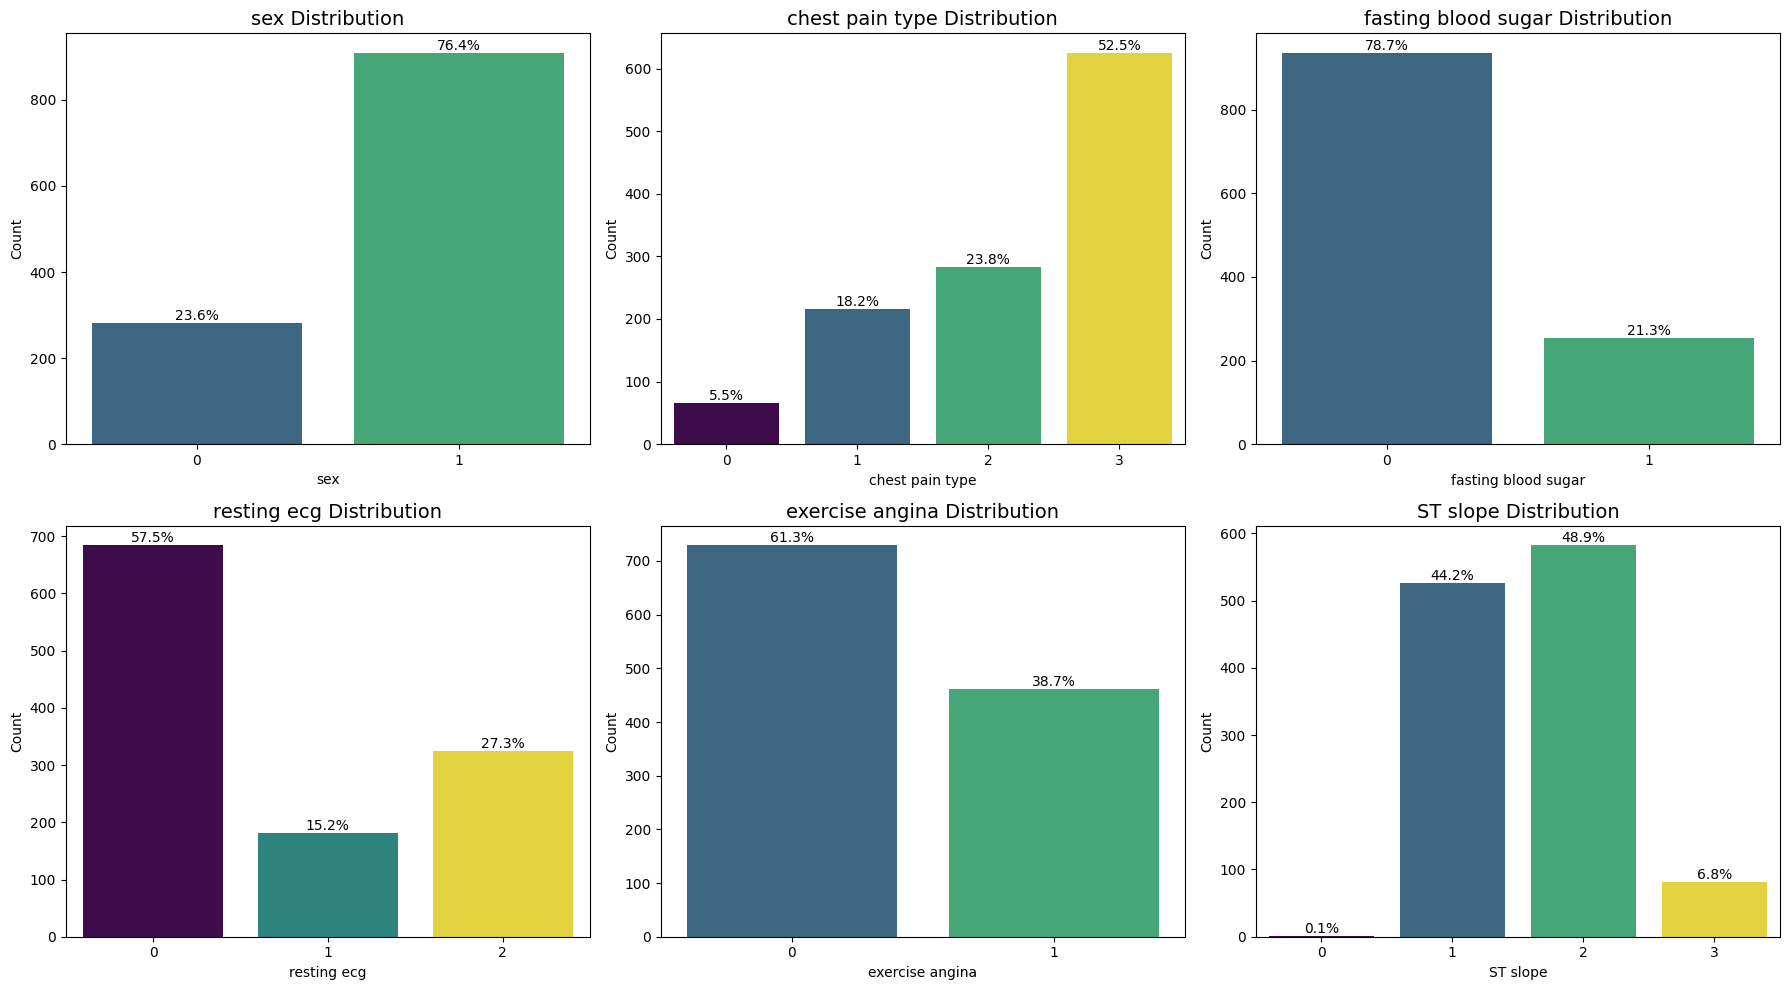

In [ ]:

# Set up the plot grid
rows = 2
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 10))

# Flatten the axes array
axes = axes.flatten()

# Loop through each categorical column and plot
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=data, ax=axes[i], palette='viridis',hue=col, legend=False)
    axes[i].set_title(f'{col} Distribution', fontsize=14)  # Enlarge title font size
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)

    # Annotate each bar with the percentage
    total = float(len(data[col]))
    for p in axes[i].patches:
        height = p.get_height()
        axes[i].annotate(f'{height/total:.1%}', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                        textcoords='offset points')

# Remove any extra plot
for i in range(len(categorical_cols), rows * cols):
    fig.delaxes(axes[i])

# Adjust layout
plt.tight_layout()
plt.show()


### Population Distributions

1. **Sex Distribution:**
   - The population predominantly consists of males, comprising approximately 76.4% of the total, while females make up the remaining 23.6%.

2. **Chest Pain Distribution:**
   - The distribution of chest pain types among the population is as follows:
     - *Typical angina:* 5.5%
     - *Atypical angina:* 18.2%
     - *Non-anginal pain:* 23.8%
     - *Asymptomatic:* 52.5%

3. **Fasting Blood Sugar Distribution:**
   - About 78.7% of the population has fasting blood sugar levels exceeding 120 mg/dl, whereas 21.3% have levels below this threshold.

4. **Resting Electrocardiogram (ECG) Distribution:**
   - The distribution of resting electrocardiogram results is as follows:
     - *Normal:* 57.5%
     - *ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV):* 15.2%
     - *Probable or definite left ventricular hypertrophy by Estes' criteria:* 27.3%

5. **Exercise Induced Angina Distribution:**
   - Approximately 61.3% of the population experiences exercise-induced angina, while the remaining 38.7% do not.

6. **Slope of the Peak Exercise ST Segment Distribution:**
   - The slope distribution of the peak exercise ST segment is as follows:
     - *Upsloping:* 44.2%
     - *Flat:* 48.9%
     - *Downsloping:* 6.8%



### Relationship between heart disease and sex

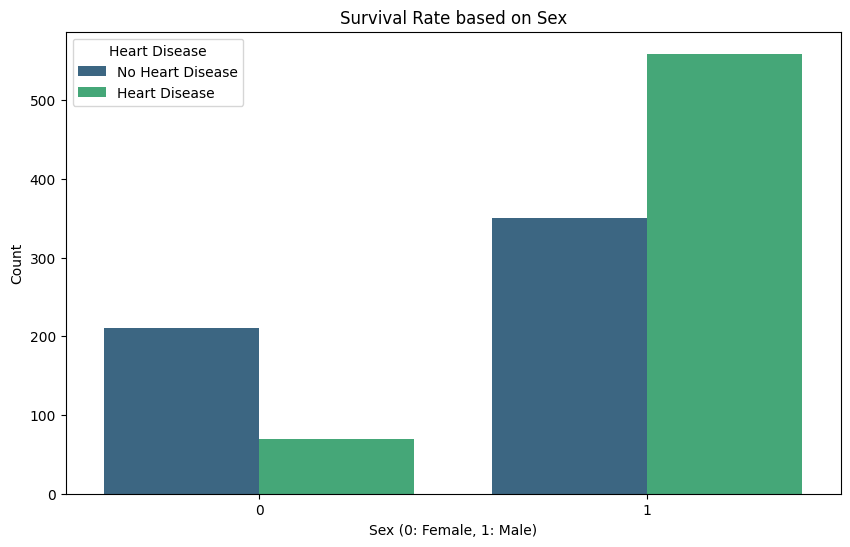

target,Survival Rate
sex,
0,0.750890
1,0.385039


In [ ]:
# Group by sex and calculate survival rate
sex_survival = data.groupby(['sex', 'target']).size().unstack(fill_value=0)
sex_survival['Survival Rate'] = sex_survival[0] / (sex_survival[0] + sex_survival[1])

# Plot
plt.figure(figsize=(10, 6))
sns.countplot(x='sex', hue='target', data=data, palette='viridis')
plt.xlabel('Sex (0: Female, 1: Male)')
plt.ylabel('Count')
plt.title('Survival Rate based on Sex')
plt.legend(title='Heart Disease', labels=['No Heart Disease', 'Heart Disease'])
plt.show()

# Display survival rates
sex_survival[['Survival Rate']]


### Relationship between survival rate  and chest pain types

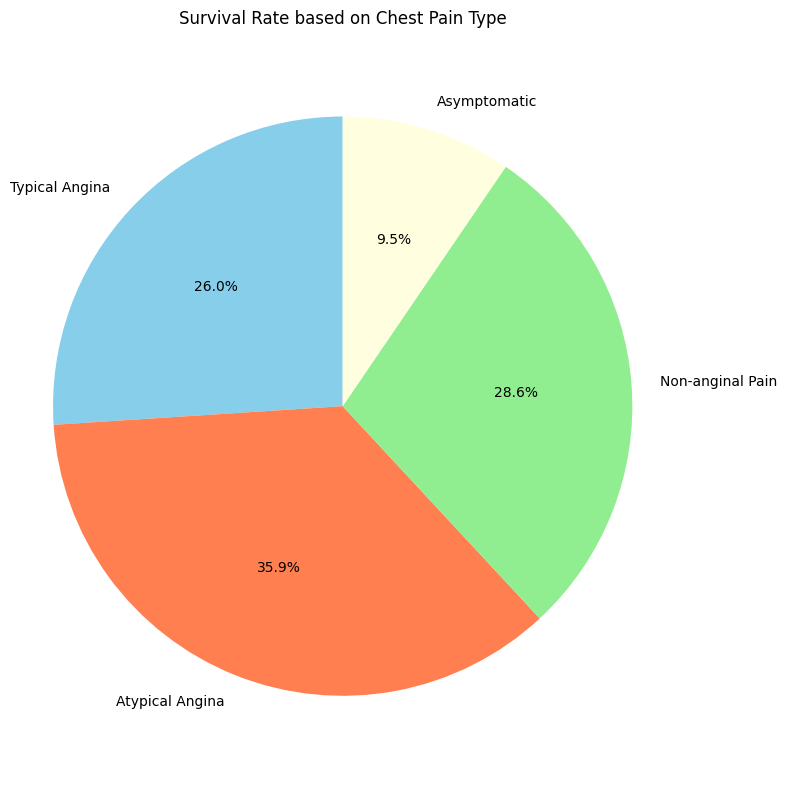

target           Survival Rate
chest pain type               
0                     0.621212
1                     0.856481
2                     0.681979
3                     0.227200


In [ ]:
# Group by chest pain type and calculate survival rate
chest_pain_survival = data.groupby(['chest pain type', 'target']).size().unstack(fill_value=0)
chest_pain_survival['Survival Rate'] = chest_pain_survival[0] / (chest_pain_survival[0] + chest_pain_survival[1])

# Plot
plt.figure(figsize=(8, 8))
labels = ['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic']
colors = ['skyblue', 'coral', 'lightgreen', 'lightyellow']
plt.pie(chest_pain_survival['Survival Rate'], labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Survival Rate based on Chest Pain Type')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

# Display survival rates
print(chest_pain_survival[['Survival Rate']])


### Relationship between survival rate  and fasting blood sugar levels

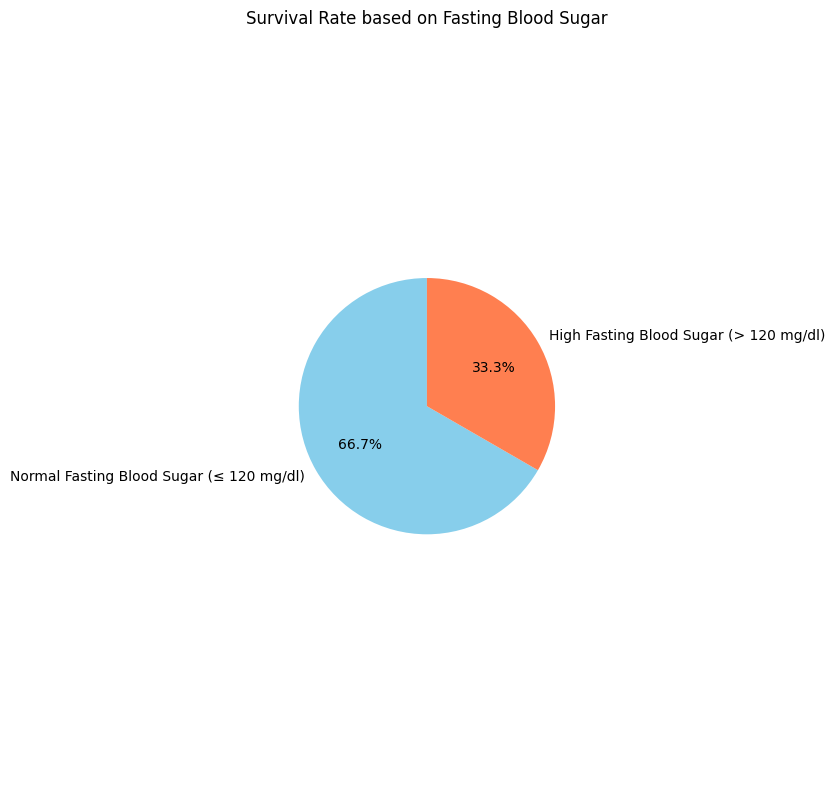

target               Survival Rate
fasting blood sugar               
0                         0.527778
1                         0.263780


In [ ]:
# Group by fasting blood sugar and calculate survival rate
fbs_survival = data.groupby(['fasting blood sugar', 'target']).size().unstack(fill_value=0)
fbs_survival['Survival Rate'] = fbs_survival[0] / (fbs_survival[0] + fbs_survival[1])

# Plot
plt.figure(figsize=(8, 8))
labels = ['Normal Fasting Blood Sugar (≤ 120 mg/dl)', 'High Fasting Blood Sugar (> 120 mg/dl)']
colors = ['skyblue', 'coral']
plt.pie(fbs_survival['Survival Rate'], labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Survival Rate based on Fasting Blood Sugar')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

# Display survival rates
print(fbs_survival[['Survival Rate']])


### Relationship between survival rate  and resting Electocardiogram Results

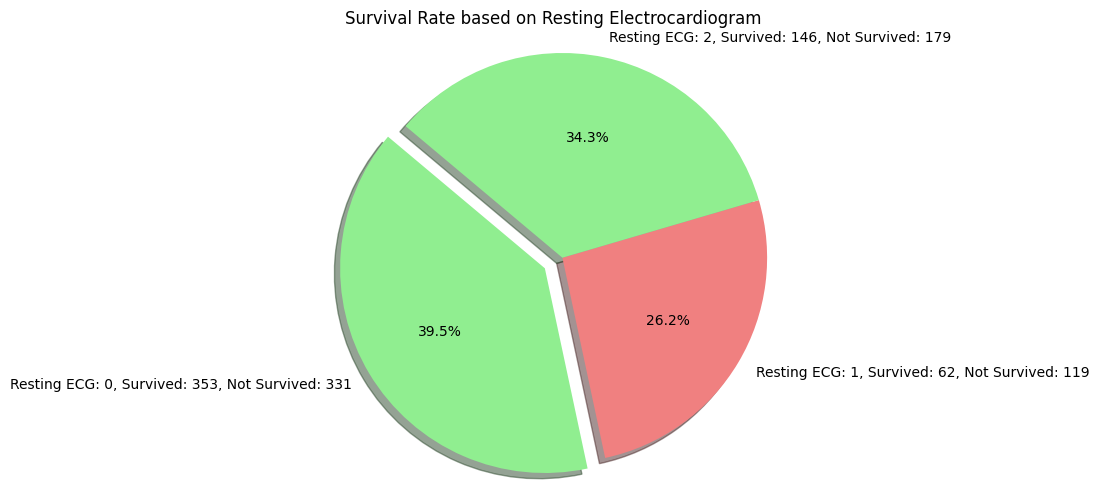

target       Survival Rate
resting ecg               
0                 0.516082
1                 0.342541
2                 0.449231


In [ ]:
# Group by resting electrocardiogram and calculate survival rate
ecg_survival = data.groupby(['resting ecg', 'target']).size().unstack(fill_value=0)
ecg_survival['Survival Rate'] = ecg_survival[0] / (ecg_survival[0] + ecg_survival[1])

# Create labels for the pie chart
labels = [f"Resting ECG: {ecg}, Survived: {ecg_survival.loc[ecg, 0]}, Not Survived: {ecg_survival.loc[ecg, 1]}"
          for ecg in ecg_survival.index]

# Create a pie chart
sizes = ecg_survival['Survival Rate'].values
colors = ['lightgreen', 'lightcoral']
explode = (0.1, 0, 0)  # "explode" the "Normal", "ST-T wave abnormality", and "Left ventricular hypertrophy" categories for emphasis

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.title('Survival Rate based on Resting Electrocardiogram')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.show()

# Display survival rates
print(ecg_survival[['Survival Rate']])


### Relationship between survival rate  and Exercise angina

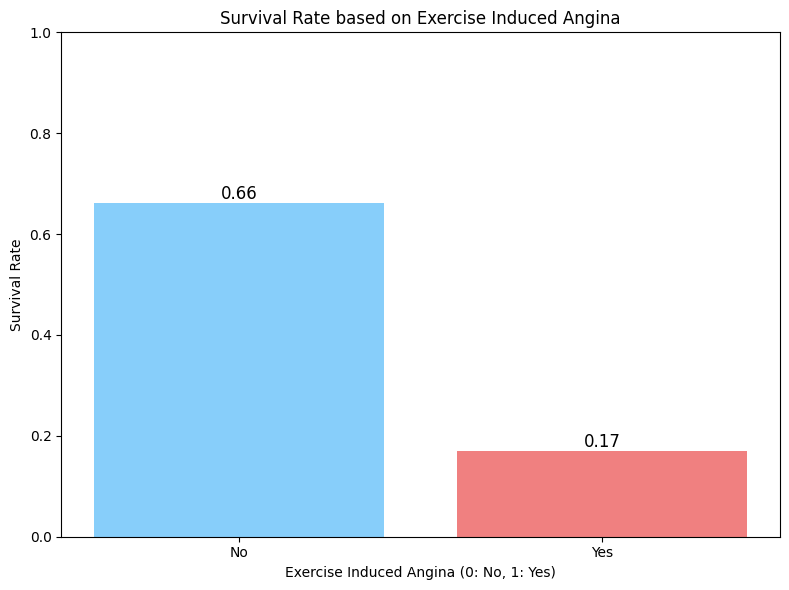

target           Survival Rate
exercise angina               
0                     0.662551
1                     0.169197


In [ ]:
# Group by exercise induced angina and calculate survival rate
exercise_angina_survival = data.groupby(['exercise angina', 'target']).size().unstack(fill_value=0)
exercise_angina_survival['Survival Rate'] = exercise_angina_survival[0] / (exercise_angina_survival[0] + exercise_angina_survival[1])

# Create a vertical bar chart
plt.figure(figsize=(8, 6))
colors = ['lightskyblue', 'lightcoral']

# Bar heights
bars = plt.bar(exercise_angina_survival.index, exercise_angina_survival['Survival Rate'], color=colors)

# Add data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', va='bottom', ha='center', fontsize=12, color='black')

plt.xlabel('Exercise Induced Angina (0: No, 1: Yes)')
plt.ylabel('Survival Rate')
plt.title('Survival Rate based on Exercise Induced Angina')
plt.ylim(0, 1)  # Set y-axis limit from 0 to 1 for better visualization
plt.xticks(exercise_angina_survival.index, ['No', 'Yes'])
plt.tight_layout()
plt.show()

# Display survival rates
print(exercise_angina_survival[['Survival Rate']])


### Survival Analysis based on Slope of the Peak Exercise ST Segment

<ipython-input-17-870af805fe29>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ST Slope', y='Count', data=st_slope_counts_table, palette='pastel')


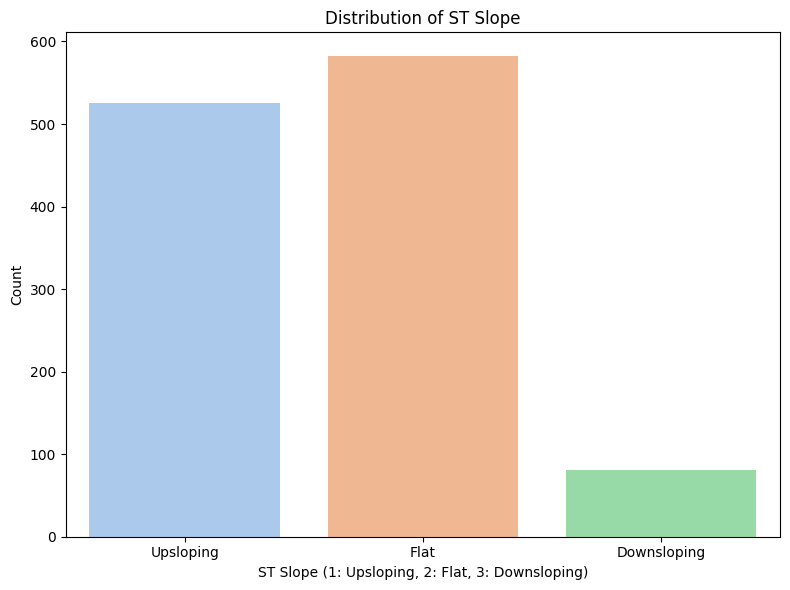

ST Slope Distribution and Survival Rate:
      ST Slope  Count  Survived (%)  Not Survived (%)
0    Upsloping    526         79.09             20.91
1         Flat    582         21.13             78.87
2  Downsloping     81         27.16             72.84


In [ ]:
# Calculate count and survival rate for each ST slope
st_slope_counts = data['ST slope'].value_counts()
survival_count_st_slope = data.groupby('ST slope')['target'].value_counts(normalize=True).unstack() * 100

# Create a DataFrame for ST slope distribution with count and survival percentages
st_slope_counts_table = pd.DataFrame({
    'ST Slope': ['Upsloping', 'Flat', 'Downsloping'],
    'Count': [st_slope_counts.get(1, 0), st_slope_counts.get(2, 0), st_slope_counts.get(3, 0)],
    'Survived (%)': [survival_count_st_slope[0].get(1, 0), survival_count_st_slope[0].get(2, 0), survival_count_st_slope[0].get(3, 0)],
    'Not Survived (%)': [survival_count_st_slope[1].get(1, 0), survival_count_st_slope[1].get(2, 0), survival_count_st_slope[1].get(3, 0)]
})

# Round the percentages to 2 decimal places
st_slope_counts_table['Survived (%)'] = st_slope_counts_table['Survived (%)'].round(2)
st_slope_counts_table['Not Survived (%)'] = st_slope_counts_table['Not Survived (%)'].round(2)

# Create a bar plot for ST slope distribution
plt.figure(figsize=(8, 6))
sns.barplot(x='ST Slope', y='Count', data=st_slope_counts_table, palette='pastel')
plt.xlabel('ST Slope (1: Upsloping, 2: Flat, 3: Downsloping)')
plt.ylabel('Count')
plt.title('Distribution of ST Slope')
plt.xticks(ticks=[0, 1, 2], labels=['Upsloping', 'Flat', 'Downsloping'])
plt.tight_layout()
plt.show()

# Display the DataFrame with count and survival percentages
print("ST Slope Distribution and Survival Rate:")
print(st_slope_counts_table)


### Relationship between Age and Survival

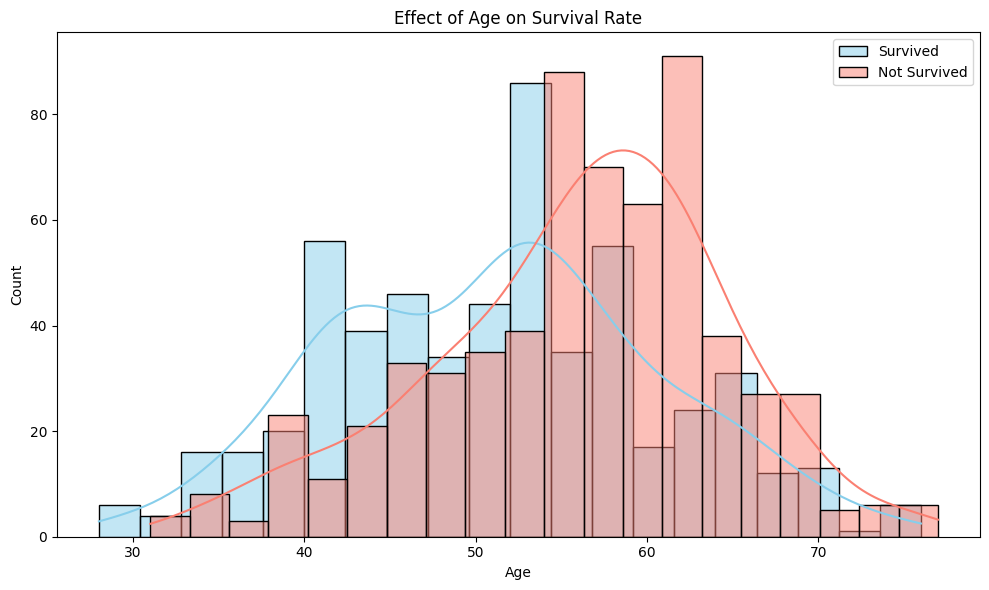

Survival Summary based on Age:
  Survival Status   Mean Age  Median Age  Min Age  Max Age
0        Survived  51.124777        51.0       28       76
1    Not Survived  56.034976        57.0       31       77


In [ ]:
# Filter data for survived and not survived groups
survived = data[data["target"] == 0]["age"]
not_survived = data[data["target"] == 1]["age"]

# Create a histogram for survived and not survived
plt.figure(figsize=(10, 6))
sns.histplot(survived, bins=20, kde=True, label="Survived", color="skyblue")
sns.histplot(not_survived, bins=20, kde=True, label="Not Survived", color="salmon")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Effect of Age on Survival Rate")
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

# Tabulate relevant data
survival_summary = pd.DataFrame({
    "Survival Status": ["Survived", "Not Survived"],
    "Mean Age": [survived.mean(), not_survived.mean()],
    "Median Age": [survived.median(), not_survived.median()],
    "Min Age": [survived.min(), not_survived.min()],
    "Max Age": [survived.max(), not_survived.max()]
})

print("Survival Summary based on Age:")
print(survival_summary)


### **Check out the Heatmap**

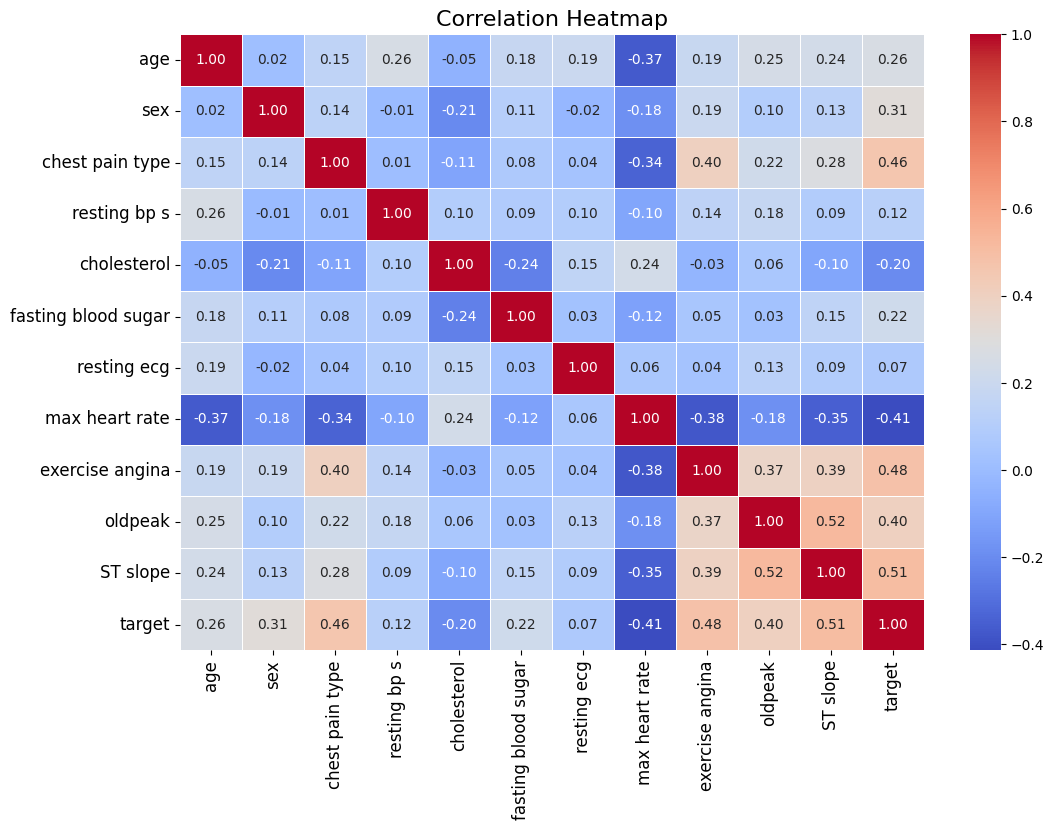

In [ ]:
#draw the data heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

## Quantitative Variables


resting bp s

cholesterol

max heart rate

oldpeak

### resting bp s vs. Survival Status

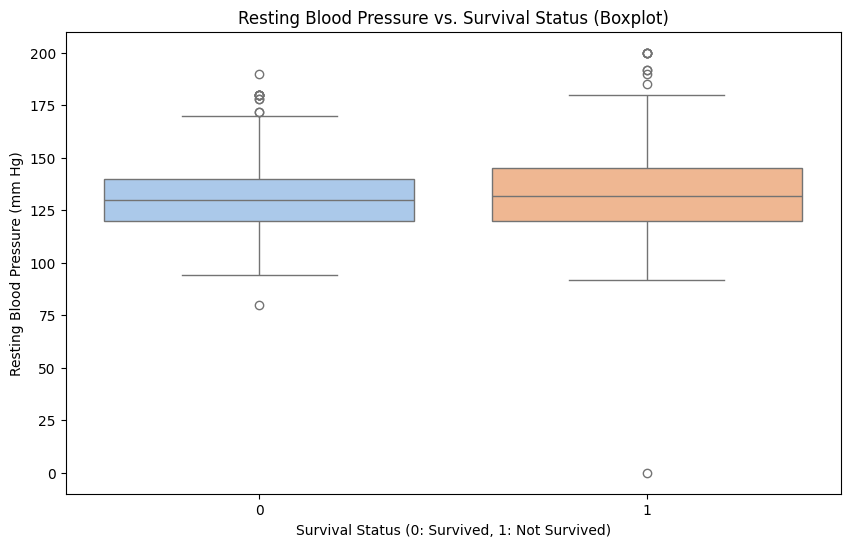

Resting Blood Pressure Distribution and Survival Rate:
                    Survived  Not Survived
Survival Rate (%)  47.142857     52.857143


In [ ]:
# Boxplot for resting bp s vs. Survival Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='resting bp s', data=data, palette='pastel', legend=False, hue='target')
plt.xlabel('Survival Status (0: Survived, 1: Not Survived)')
plt.ylabel('Resting Blood Pressure (mm Hg)')
plt.title('Resting Blood Pressure vs. Survival Status (Boxplot)')
plt.show()

# Calculate survival rate based on resting bp s
resting_bp_survived = data[data['target'] == 0]['resting bp s'].count()
resting_bp_not_survived = data[data['target'] == 1]['resting bp s'].count()
total_resting_bp = resting_bp_survived + resting_bp_not_survived
survival_rate_resting_bp = resting_bp_survived / total_resting_bp * 100
non_survival_rate_resting_bp = resting_bp_not_survived / total_resting_bp * 100
resting_bp_table = pd.DataFrame({'Survived': [survival_rate_resting_bp],
                                 'Not Survived': [non_survival_rate_resting_bp]},
                                index=['Survival Rate (%)'])
print("Resting Blood Pressure Distribution and Survival Rate:")
print(resting_bp_table)


### cholesterol vs. Survival Status

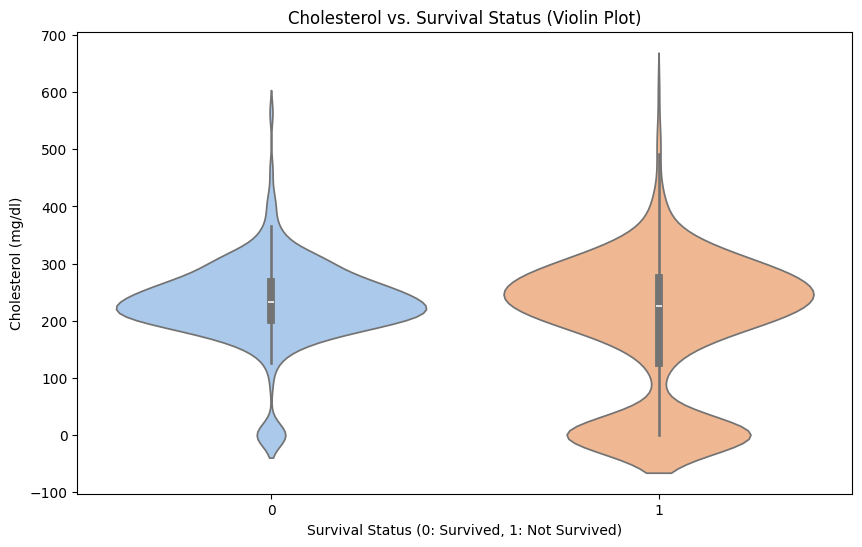

Cholesterol Distribution and Survival Rate:
                    Survived  Not Survived
Survival Rate (%)  47.142857     52.857143


In [ ]:
# Violin Plot for Cholesterol vs. Survival Status
plt.figure(figsize=(10, 6))
sns.violinplot(x='target', y='cholesterol', data=data, palette='pastel', legend=False, hue='target')
plt.xlabel('Survival Status (0: Survived, 1: Not Survived)')
plt.ylabel('Cholesterol (mg/dl)')
plt.title('Cholesterol vs. Survival Status (Violin Plot)')
plt.show()

# Calculate survival rate based on Cholesterol
cholesterol_survived = data[data['target'] == 0]['cholesterol'].count()
cholesterol_not_survived = data[data['target'] == 1]['cholesterol'].count()
total_cholesterol = cholesterol_survived + cholesterol_not_survived
survival_rate_cholesterol = cholesterol_survived / total_cholesterol * 100
non_survival_rate_cholesterol = cholesterol_not_survived / total_cholesterol * 100
cholesterol_table = pd.DataFrame({'Survived': [survival_rate_cholesterol],
                                  'Not Survived': [non_survival_rate_cholesterol]},
                                 index=['Survival Rate (%)'])
print("Cholesterol Distribution and Survival Rate:")
print(cholesterol_table)


### max heart rate vs. Survival Status

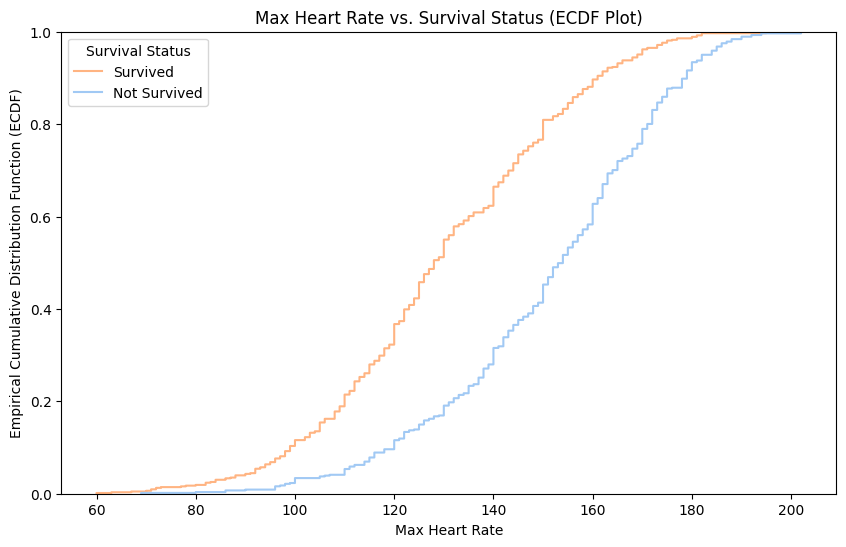

Max Heart Rate Distribution and Survival Rate:
                    Survived  Not Survived
Survival Rate (%)  47.142857     52.857143


In [ ]:
# ECDF Plot for Max Heart Rate vs. Survival Status
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=data, x='max heart rate', hue='target', palette='pastel')
plt.xlabel('Max Heart Rate')
plt.ylabel('Empirical Cumulative Distribution Function (ECDF)')
plt.title('Max Heart Rate vs. Survival Status (ECDF Plot)')
plt.legend(title='Survival Status', labels=['Survived', 'Not Survived'])
plt.show()

# Calculate survival rate based on Max Heart Rate
max_hr_survived = data[data['target'] == 0]['max heart rate'].count()
max_hr_not_survived = data[data['target'] == 1]['max heart rate'].count()
total_max_hr = max_hr_survived + max_hr_not_survived
survival_rate_max_hr = max_hr_survived / total_max_hr * 100
non_survival_rate_max_hr = max_hr_not_survived / total_max_hr * 100
max_hr_table = pd.DataFrame({'Survived': [survival_rate_max_hr],
                             'Not Survived': [non_survival_rate_max_hr]},
                            index=['Survival Rate (%)'])
print("Max Heart Rate Distribution and Survival Rate:")
print(max_hr_table)


### oldpeak vs. Survival Status

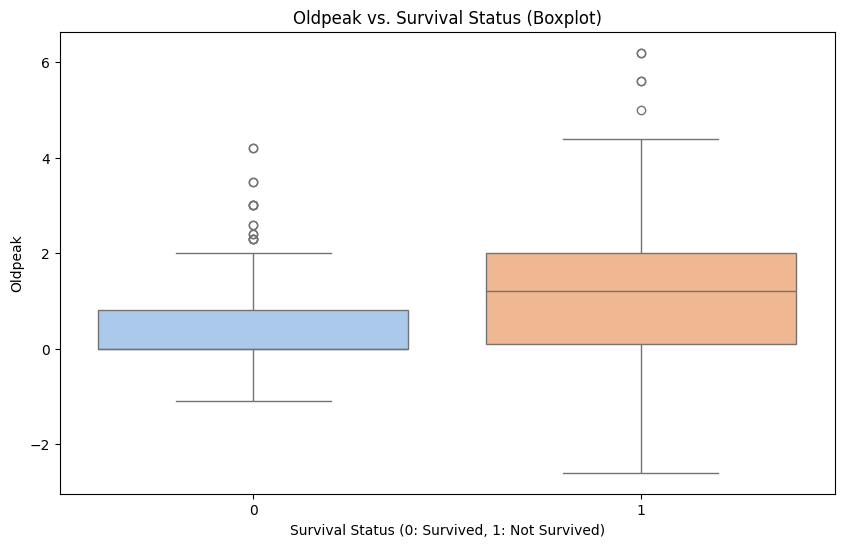

Oldpeak Distribution and Survival Rate:
                    Survived  Not Survived
Survival Rate (%)  47.142857     52.857143


In [ ]:
# Boxplot for Oldpeak vs. Survival Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='oldpeak', data=data, palette='pastel', legend=False, hue='target')
plt.xlabel('Survival Status (0: Survived, 1: Not Survived)')
plt.ylabel('Oldpeak')
plt.title('Oldpeak vs. Survival Status (Boxplot)')
plt.show()

# Calculate survival rate based on Oldpeak
oldpeak_survived = data[data['target'] == 0]['oldpeak'].count()
oldpeak_not_survived = data[data['target'] == 1]['oldpeak'].count()
total_oldpeak = oldpeak_survived + oldpeak_not_survived
survival_rate_oldpeak = oldpeak_survived / total_oldpeak * 100
non_survival_rate_oldpeak = oldpeak_not_survived / total_oldpeak * 100
oldpeak_table = pd.DataFrame({'Survived': [survival_rate_oldpeak],
                              'Not Survived': [non_survival_rate_oldpeak]},
                             index=['Survival Rate (%)'])
print("Oldpeak Distribution and Survival Rate:")
print(oldpeak_table)




### Normalize the data

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# List of numerical features
numerical_num = ['resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']

# Extract the numerical columns from the DataFrame
numerical_data = data[numerical_num]

# Standardization with StandardScaler
scaler_standard = StandardScaler()
X_standardized = scaler_standard.fit_transform(numerical_data)

# Normalization with MinMaxScaler
scaler_minmax = MinMaxScaler()
X_normalized_standardized = scaler_minmax.fit_transform(X_standardized)

# Convert the scaled data back to a DataFrame
df_scaled = pd.DataFrame(X_normalized_standardized, columns=numerical_num)

# Display the scaled DataFrame
print(df_scaled.head())


   resting bp s  cholesterol  max heart rate   oldpeak
0          0.70     0.479270        0.788732  0.295455
1          0.80     0.298507        0.676056  0.409091
2          0.65     0.469320        0.267606  0.295455
3          0.69     0.354892        0.338028  0.465909
4          0.75     0.323383        0.436620  0.295455


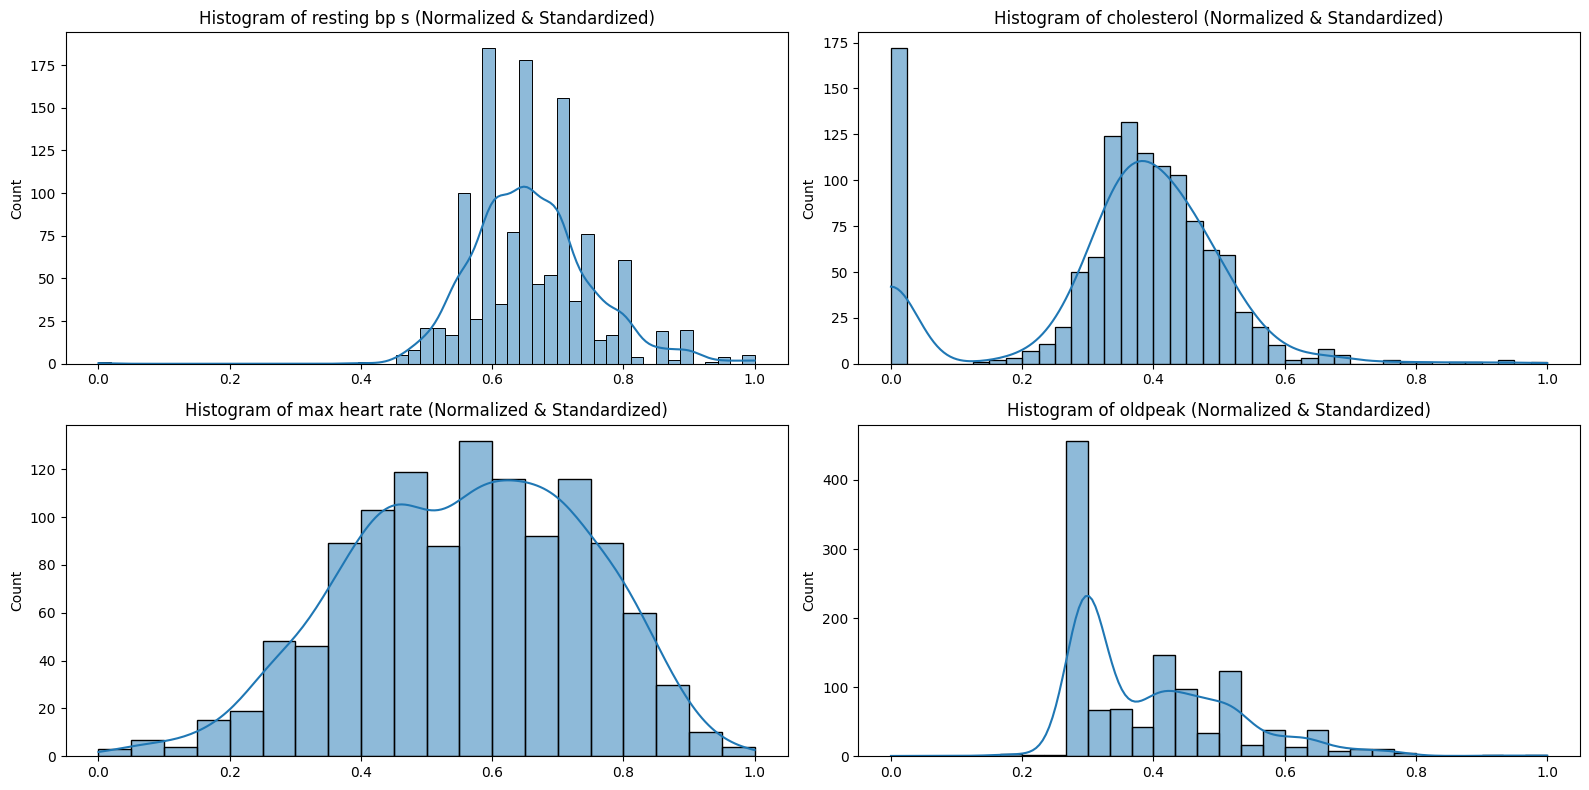

In [ ]:
# Plot histograms for each feature in the scaled numerical columns
plt.figure(figsize=(16, 8))  # Larger figure size
for i, col in enumerate(numerical_num):
    plt.subplot(2, len(numerical_num)//2 + len(numerical_num)%2, i + 1)
    sns.histplot(X_normalized_standardized[:, i], kde=True)
    plt.title(f'Histogram of {col} (Normalized & Standardized)')
plt.tight_layout()
plt.show()


In [ ]:
# Save preprocessed data to a new CSV file
# Replace original numerical columns with scaled ones
data[numerical_num] = X_normalized_standardized

# Save preprocessed data to a new CSV file
data.to_csv('preprocessed_heart_statlog_cleveland_hungary_final_scaled.csv', index=False)

print("Preprocessing completed. Preprocessed data saved to 'preprocessed_heart_statlog_cleveland_hungary_final_scaled.csv'")


Preprocessing completed. Preprocessed data saved to 'preprocessed_heart_statlog_cleveland_hungary_final_scaled.csv'


## Feature Importance

In [ ]:
#Load data
df = pd.read_csv('preprocessed_heart_statlog_cleveland_hungary_final_scaled.csv')
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,1,0.70,0.479270,0,0,0.788732,0,0.295455,1,0
1,49,0,2,0.80,0.298507,0,0,0.676056,0,0.409091,2,1
2,37,1,1,0.65,0.469320,0,1,0.267606,0,0.295455,1,0
3,48,0,3,0.69,0.354892,0,0,0.338028,1,0.465909,2,1
4,54,1,2,0.75,0.323383,0,0,0.436620,0,0.295455,1,0


### Split the Data
Split the data into features (X) and the target variable (y), then further split it into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into features (X) and target variable (y)
X = df.drop(['target'], axis=1)
y = df['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


### Checking feature importance using Random Forest Classifier

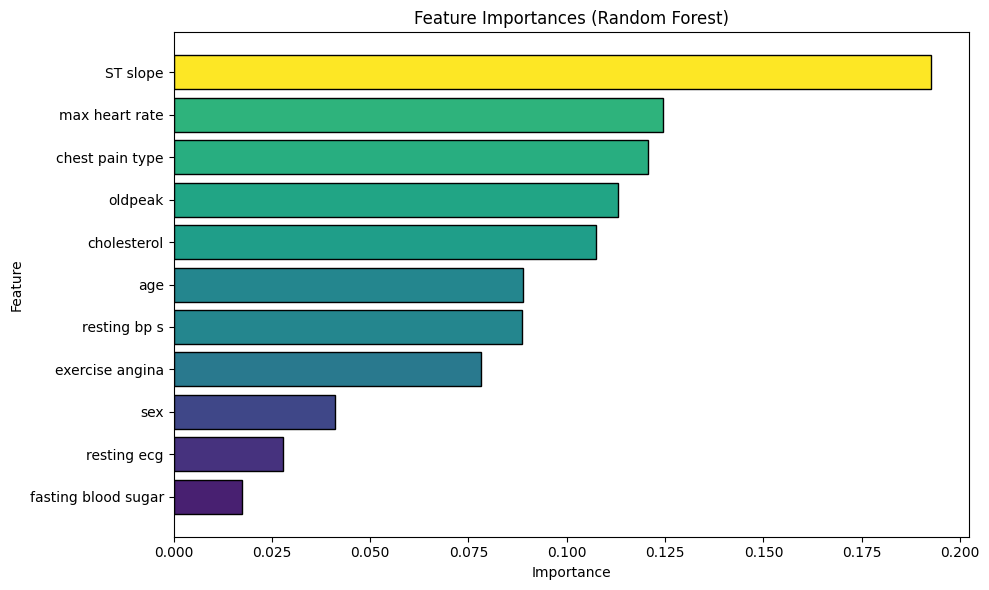

Random Forest Feature Importances:
                Feature  Importance
10             ST slope    0.192730
7        max heart rate    0.124538
2       chest pain type    0.120720
9               oldpeak    0.113135
4           cholesterol    0.107325
0                   age    0.088760
3          resting bp s    0.088496
8       exercise angina    0.078076
1                   sex    0.041125
6           resting ecg    0.027780
5   fasting blood sugar    0.017315


In [ ]:
# Train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances_rf = rf_model.feature_importances_

feature_importance_df_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances_rf
})

# Sort the features by importance in descending order
sorted_features_rf = feature_importance_df_rf.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
bars = plt.barh(sorted_features_rf['Feature'], sorted_features_rf['Importance'],
                color=plt.cm.viridis(sorted_features_rf['Importance'] / max(sorted_features_rf['Importance'])), edgecolor='black')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances (Random Forest)')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top

plt.tight_layout()  # Adjust layout to ensure everything fits within the figure
plt.show()

# List the features in order of importance
print("Random Forest Feature Importances:")
print(sorted_features_rf)

### Checking feature importance using XGBoost Classifier

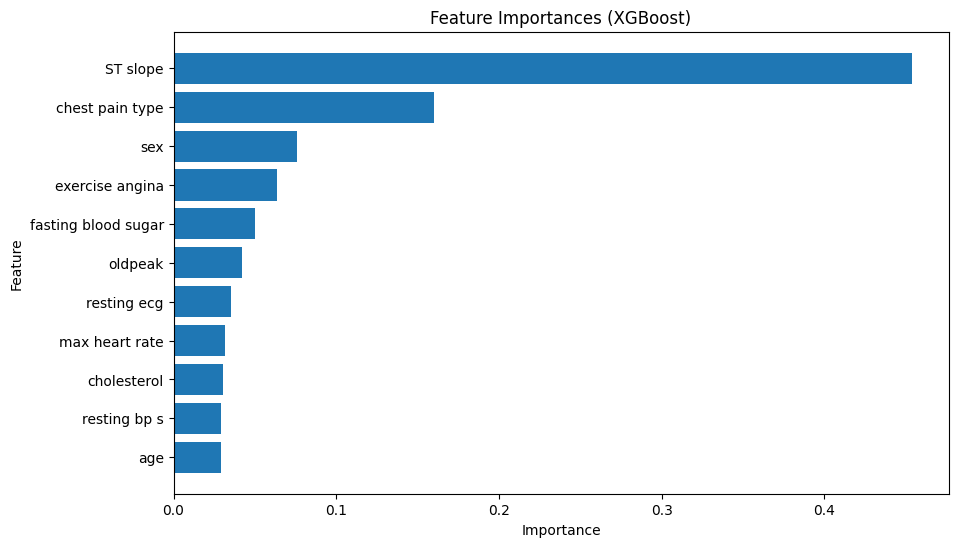

XGBoost Feature Importances:
                Feature  Importance
10             ST slope    0.453606
2       chest pain type    0.159793
1                   sex    0.075785
8       exercise angina    0.063369
5   fasting blood sugar    0.049793
9               oldpeak    0.042023
6           resting ecg    0.035158
7        max heart rate    0.031538
4           cholesterol    0.030226
3          resting bp s    0.029451
0                   age    0.029258


In [ ]:
import xgboost as xgb
# Train the XGBoost model
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)

# Get feature importances
feature_importances_xgb = xgb_model.feature_importances_

# Create a DataFrame to store feature importances along with their names
feature_importance_df_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances_xgb
})

# Sort the features by importance in descending order
sorted_features_xgb = feature_importance_df_xgb.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(sorted_features_xgb['Feature'], sorted_features_xgb['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances (XGBoost)')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.show()

# List the features in order of importance
print("XGBoost Feature Importances:")
print(sorted_features_xgb)


### Logistic Regression Feature Importance

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


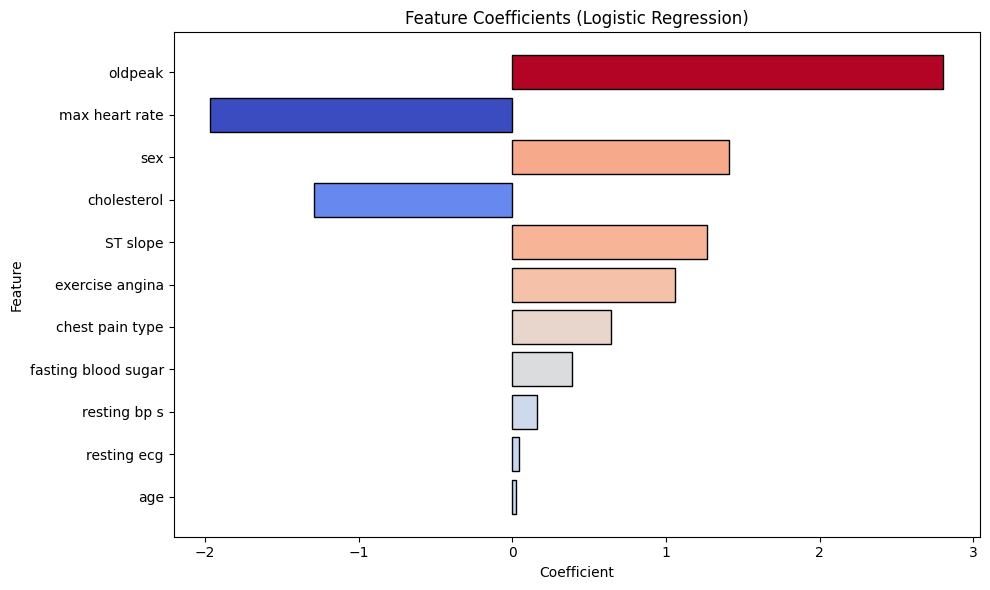

Logistic Regression Feature Coefficients:
                Feature  Coefficient
9               oldpeak     2.804145
7        max heart rate    -1.965674
1                   sex     1.407409
4           cholesterol    -1.288869
10             ST slope     1.268973
8       exercise angina     1.060829
2       chest pain type     0.639191
5   fasting blood sugar     0.388353
3          resting bp s     0.160217
6           resting ecg     0.044039
0                   age     0.026538


In [ ]:
# Train the Logistic Regression model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

# Get feature coefficients
feature_coefficients_lr = lr_model.coef_[0]

# Create a DataFrame to store feature coefficients along with their names
feature_importance_df_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': feature_coefficients_lr
})

# Sort the features by coefficient magnitude
sorted_features_lr = feature_importance_df_lr.reindex(feature_importance_df_lr['Coefficient'].abs().sort_values(ascending=False).index)

# Plot the feature coefficients
plt.figure(figsize=(10, 6))
bars = plt.barh(sorted_features_lr['Feature'], sorted_features_lr['Coefficient'],
                color=plt.cm.coolwarm((sorted_features_lr['Coefficient'] - sorted_features_lr['Coefficient'].min()) /
                                      (sorted_features_lr['Coefficient'].max() - sorted_features_lr['Coefficient'].min())), edgecolor='black')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Feature Coefficients (Logistic Regression)')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top

plt.tight_layout()  # Adjust layout to ensure everything fits within the figure
plt.show()

# List the features in order of importance
print("Logistic Regression Feature Coefficients:")
print(sorted_features_lr)

### Decision Tree Feature Importance

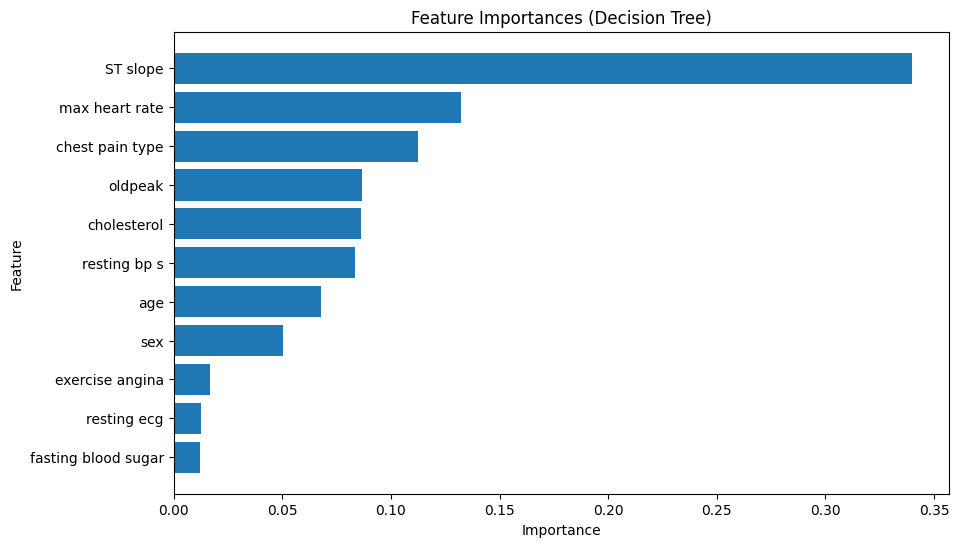

Decision Tree Feature Importances:
                Feature  Importance
10             ST slope    0.339629
7        max heart rate    0.132124
2       chest pain type    0.112273
9               oldpeak    0.086871
4           cholesterol    0.086163
3          resting bp s    0.083294
0                   age    0.067669
1                   sex    0.050323
8       exercise angina    0.016731
6           resting ecg    0.012604
5   fasting blood sugar    0.012319


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train the Decision Tree model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# Get feature importances
feature_importances_dt = dt_model.feature_importances_

# Create a DataFrame to store feature importances along with their names
feature_importance_df_dt = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances_dt
})

# Sort the features by importance in descending order
sorted_features_dt = feature_importance_df_dt.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(sorted_features_dt['Feature'], sorted_features_dt['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances (Decision Tree)')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.show()

# List the features in order of importance
print("Decision Tree Feature Importances:")
print(sorted_features_dt)


# Based on the feature importances from different models, here are some useful inferences:

## 1. Consistently Important Features:
- Across Random Forest, XGBoost, Decision Tree, and Logistic Regression, features like 'ST slope', 'max heart rate', 'chest pain type', and 'oldpeak' appear to be consistently important. This consistency suggests that these features strongly influence the prediction of heart disease across different modeling techniques.

## 2. Varying Importance:
- While some features like 'ST slope' consistently appear to be highly important across all models, others such as 'sex' and 'resting ecg' show varying importance depending on the model. This variation may be due to differences in how each model weighs the importance of features.

## 3. Key Features:
- Features like 'ST slope', 'max heart rate', and 'chest pain type' consistently stand out as key predictors of heart disease across all models. These features likely contain critical information about the cardiovascular health of patients and should be given particular attention in further analysis or medical evaluations.

## 4. Influence of Risk Factors:
- Risk factors such as 'cholesterol' and 'exercise angina' also appear prominently in some models. High cholesterol levels ('cholesterol') and the presence of exercise-induced angina ('exercise angina') are well-known risk factors for heart disease, so their importance in predicting heart disease is consistent with medical knowledge.

## 5. Age and Gender:
- Interestingly, 'age' and 'sex' show varying importance across different models. While 'age' tends to have lower importance compared to other features, 'sex' appears to have a more significant influence in some models like XGBoost and Logistic Regression. This suggests that gender may play a more pronounced role in certain predictive models.


### Check for class imbalance

In [ ]:
# Calculate class distribution in training set
train_class_counts = y_train.value_counts()

# Calculate class distribution in testing set
test_class_counts = y_test.value_counts()

print("Training Class Distribution:")
print(train_class_counts)

print("\nTesting Class Distribution:")
print(test_class_counts)

Training Class Distribution:
target
1    502
0    450
Name: count, dtype: int64

Testing Class Distribution:
target
1    127
0    111
Name: count, dtype: int64



**Inference**:
- The class distribution of the target variable 'Class' in both the training and testing sets indicates a relatively balanced distribution, with slightly more instances labeled as '1' (Heart Disease) compared to '0' (Normal). This balanced distribution suggests that there may not be a significant issue with class imbalance in this dataset. However, it's important to note that class imbalance may still lead to biased model predictions, particularly for the minority class ('1'). To address this imbalance and improve the model's ability to learn from the minority class, it is advisable to use Synthetic Minority Over-sampling Technique (SMOTE) to create synthetic samples of the minority class and balance the dataset.



### Implement SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
sampling = SMOTE(random_state=100)
X_train_resampled, y_train_resampled = sampling.fit_resample(X_train, y_train)

# Shuffle the data
perms = np.random.permutation(X_train_resampled.shape[0])
X_train_resampled = X_train_resampled.iloc[perms].reset_index(drop=True)
y_train_resampled = y_train_resampled.iloc[perms].reset_index(drop=True)

# Check the shape after shuffling
print("Training Data After SMOTE and Shuffling:")
print("X_train_resampled shape:", X_train_resampled.shape)
print("y_train_resampled shape:", y_train_resampled.shape)

Training Data After SMOTE and Shuffling:
X_train_resampled shape: (1004, 11)
y_train_resampled shape: (1004,)


## Model Training

### Supervised Learning Models

Random Forest Classifier

Support Vector Machine (SVM)

Logistic Regression

Gradient Boosting Classifier - XGBoost

LightGBM

### Random Forest Classifier

In [ ]:
# Create the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=100)

# Train the Random Forest model on the resampled data
rf_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test data
y_pred = rf_model.predict(X_test)

# Generate the classification report
classification_rep = classification_report(y_test, y_pred)

# Print the classification report
print("Classification Report:")
print(classification_rep)

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       111
           1       0.96      0.97      0.96       127

    accuracy                           0.96       238
   macro avg       0.96      0.96      0.96       238
weighted avg       0.96      0.96      0.96       238



### Tune the hyperparameters of the Random Forest Classifier


Best Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 14}

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       111
           1       0.96      0.97      0.96       127

    accuracy                           0.96       238
   macro avg       0.96      0.96      0.96       238
weighted avg       0.96      0.96      0.96       238



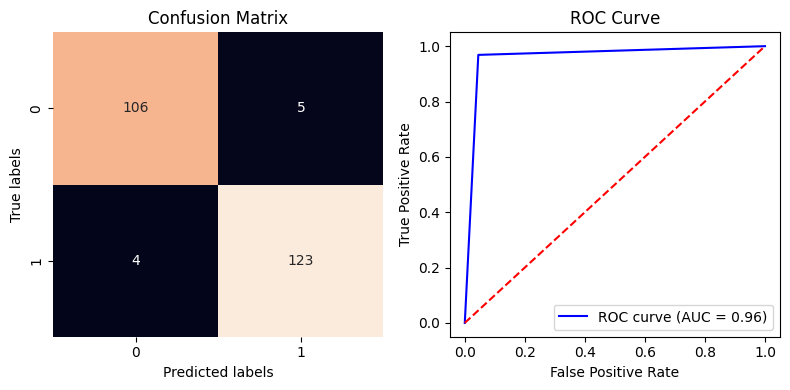

In [ ]:
# Random Forest with Hyperparameters Tuning
rn_forest = RandomForestClassifier(random_state=100)

# Parameters to build the model on
param_grid = {
    'max_depth': range(1, 15),
    'n_estimators': [50, 100, 300],
    'max_features': ['auto', 'sqrt', 'log2'],
    'min_samples_split': [2, 3, 5, 7, 9],
    'min_samples_leaf': [1, 2, 4, 6, 8]
}

# Instantiate RandomizedSearchCV object
forest_grid = RandomizedSearchCV(rn_forest, param_grid, cv=5, n_jobs=-1, random_state=3)

# Fit the model to the resampled training data
forest_grid.fit(X_train_resampled, y_train_resampled)

# Get the best parameters from grid search and store in best_params
best_params_rf = forest_grid.best_params_
print("\nBest Parameters:", best_params_rf)

# Get the best classifier model after hyperparameter tuning
best_forest = forest_grid.best_estimator_

# Fit the best model to the resampled training data
best_forest.fit(X_train_resampled, y_train_resampled)

# Generate the model test classification report for Tuned Random Forest
y_pred_tuned = best_forest.predict(X_test)
rf_report_tuned = classification_report(y_test, y_pred_tuned)

print("\nTuned Random Forest Classification Report:")
print(rf_report_tuned)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)

# Calculate the AUC score
auc_score = roc_auc_score(y_test, y_pred_tuned)

# Calculate the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_tuned)

# Plot confusion matrix and ROC curve side by side
plt.figure(figsize=(8, 4))

# Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='blue', label='ROC curve (AUC = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()


## Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

# Support Vector Machine (SVM) with Default Parameters
svm_default = SVC(random_state=42)
svm_default.fit(X_train_resampled, y_train_resampled)

# Generate the model test classification report for Default SVM
y_pred_svm_default = svm_default.predict(X_test)
report_svm_default = classification_report(y_test, y_pred_svm_default)
print("Default SVM Classification Report:")
print(report_svm_default)

Default SVM Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.64      0.68       111
           1       0.71      0.78      0.74       127

    accuracy                           0.71       238
   macro avg       0.71      0.71      0.71       238
weighted avg       0.71      0.71      0.71       238



### Tune the hyperparameters for the Support Vector Machine (SVM) model using GridSearchCV

In [ ]:


# SVM with Hyperparameters Tuning using RandomizedSearchCV
svm_model = SVC(random_state=100)

# Define a smaller hyperparameter grid
param_grid_svm = {
    'C': [0.01, 0.1, 1],
    'gamma': [0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

# Instantiate RandomizedSearchCV
random_search_svm = RandomizedSearchCV(estimator=svm_model, param_distributions=param_grid_svm,
                                       scoring='accuracy', n_iter=10, random_state=42, cv=5, n_jobs=-1)

# Fit the RandomizedSearchCV to the training data
random_search_svm.fit(X_train_resampled, y_train_resampled)

# Get the best hyperparameters and store in best_params_svm
best_params_svm = random_search_svm.best_params_
print("Best Parameters for SVM (after tuning):")
print(best_params_svm)

# Get the best classifier model after hyperparameter tuning
best_svm_model = random_search_svm.best_estimator_

# Train the best model on the entire training set
best_svm_model.fit(X_train_resampled, y_train_resampled)

# Generate the model test classification report for Tuned SVM
y_pred_svm_tuned = best_svm_model.predict(X_test)
report_svm_tuned = classification_report(y_test, y_pred_svm_tuned)
print("\nTuned SVM Classification Report:")
print(report_svm_tuned)


### Logistic Regression

In [ ]:
# Logistic Regression before Tuning
log_reg = LogisticRegression(random_state=1)

# Fit the Logistic Regression model on the resampled training data
log_reg.fit(X_train_resampled, y_train_resampled)

# Generate the model test classification report for Logistic Regression
y_pred_log_reg = log_reg.predict(X_test)
report_log_reg = classification_report(y_test, y_pred_log_reg)
print("Logistic Regression Classification Report (Before Tuning):")
print(report_log_reg)

Logistic Regression Classification Report (Before Tuning):
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       111
           1       0.87      0.83      0.85       127

    accuracy                           0.84       238
   macro avg       0.84      0.85      0.84       238
weighted avg       0.85      0.84      0.84       238



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Tune the hyperparameters for Logistic Regression

Best Parameters for Logistic Regression: {'solver': 'liblinear', 'penalty': 'l1', 'max_iter': 500, 'class_weight': 'balanced', 'C': 1}
Tuned Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       111
           1       0.88      0.83      0.85       127

    accuracy                           0.85       238
   macro avg       0.85      0.85      0.85       238
weighted avg       0.85      0.85      0.85       238



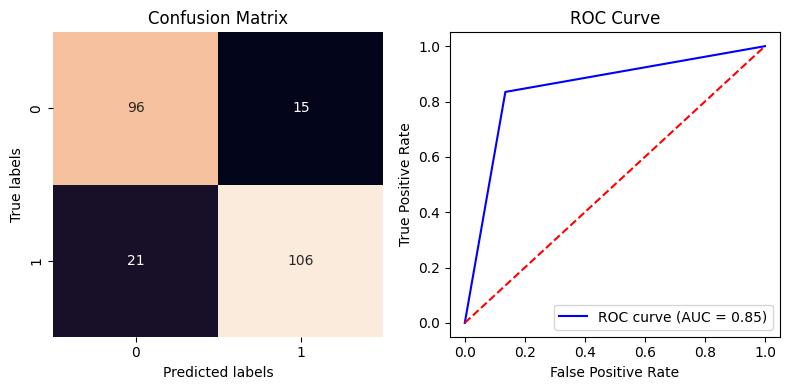

In [ ]:
# Logistic Regression with Default Parameters
lr = LogisticRegression(random_state=100)

# Parameters to build the model on
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'max_iter': [100, 200, 300, 400, 500],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced']
}

# Instantiate RandomizedSearchCV
random_search_lr = RandomizedSearchCV(lr, param_grid, cv=5, n_iter=50, scoring='accuracy', n_jobs=-1, random_state=100)

# Fit the RandomizedSearchCV to the training data
random_search_lr.fit(X_train_resampled, y_train_resampled)

# Get the best parameters and store in best_params_lr
best_params_lr = random_search_lr.best_params_
print("Best Parameters for Logistic Regression:", best_params_lr)

# Get the best classifier model after hyperparameter tuning
best_lr = random_search_lr.best_estimator_

# Fit the best model to the training data
best_lr.fit(X_train_resampled, y_train_resampled)

# Predict on the testing data
y_pred_lr = best_lr.predict(X_test)

# Generate the model test classification report
tuned_lr_report = classification_report(y_test, y_pred_lr)
print("Tuned Logistic Regression Classification Report:")
print(tuned_lr_report)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Calculate the AUC score
auc_score = roc_auc_score(y_test, y_pred_lr)

# Calculate the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_lr)

# Plot confusion matrix and ROC curve side by side
plt.figure(figsize=(8, 4))

# Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='blue', label='ROC curve (AUC = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()


### Gradient Boosting Classifier - XGBoost

In [ ]:
from xgboost import XGBClassifier

# Instantiate XGBoost Classifier
xgb_clf = XGBClassifier(random_state=100)

# Fit the classifier to the resampled training data
xgb_clf.fit(X_train_resampled, y_train_resampled)

# Predict on the original testing data
y_pred_xgb = xgb_clf.predict(X_test)

# Generate the classification report
report_xgb = classification_report(y_test, y_pred_xgb)
print("XGBoost Classification Report (without tuning, with resampling):")
print(report_xgb)

XGBoost Classification Report (without tuning, with resampling):
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       111
           1       0.96      0.94      0.95       127

    accuracy                           0.95       238
   macro avg       0.95      0.95      0.95       238
weighted avg       0.95      0.95      0.95       238



### Tune the XGBoost Classifier using RandomizedSearchCV

Best Parameters for XGBoost Classifier (with default parameters):
{'subsample': 0.8, 'n_estimators': 1000, 'min_child_weight': 2, 'max_depth': 20, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best F1 Score on Resampled Training Data: 0.9073025742845658

XGBoost Classification Report (with tuning and resampling):
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       111
           1       0.95      0.94      0.94       127

    accuracy                           0.94       238
   macro avg       0.94      0.94      0.94       238
weighted avg       0.94      0.94      0.94       238



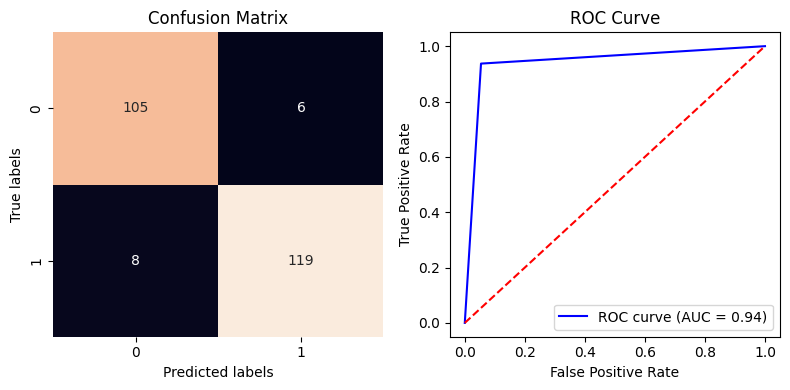

In [ ]:

# Define the XGBoost Classifier with default parameters
xgb = XGBClassifier(n_jobs=-1, random_state=1)

# Define the hyperparameters to tune
param_grid = {
    'max_depth': range(4, 40),
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.6, 0.9, 0.95, 0.99],
    'n_estimators': range(100, 1100, 100),
    'min_child_weight': range(1, 11),
    'subsample': np.arange(0.1, 1.1, 0.1),
    'colsample_bytree': np.arange(0.1, 1.1, 0.1)
}

# Instantiate RandomizedSearchCV object
xgb_grid = RandomizedSearchCV(xgb, param_grid, cv=5, n_iter=50, scoring='f1', n_jobs=-1, random_state=3)

# Fit the RandomizedSearchCV to the training data
xgb_grid.fit(X_train_resampled, y_train_resampled)

# Get the best parameters and best score
best_params_xgb = xgb_grid.best_params_
best_score_xgb = xgb_grid.best_score_

print("Best Parameters for XGBoost Classifier (with default parameters):")
print(best_params_xgb)
print("Best F1 Score on Resampled Training Data:", best_score_xgb)

# Use the best model to predict on the original testing data
best_xgb_clf = xgb_grid.best_estimator_
y_pred_xgb_tuned_default = best_xgb_clf.predict(X_test)

# Generate the classification report
report_xgb_tuned = classification_report(y_test, y_pred_xgb_tuned_default)
print("\nXGBoost Classification Report (with tuning and resampling):")
print(report_xgb_tuned)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb_tuned_default)

# Calculate the AUC score
auc_score = roc_auc_score(y_test, y_pred_xgb_tuned_default)

# Calculate the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_xgb_tuned_default)

# Plot confusion matrix and ROC curve side by side
plt.figure(figsize=(8, 4))

# Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='blue', label='ROC curve (AUC = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()


### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Instantiate Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=100)

# Fit the classifier to the training data
dt_clf.fit(X_train_resampled, y_train_resampled)

# Predict on the testing data
y_pred_dt = dt_clf.predict(X_test)

# Generate the classification report
report_dt = classification_report(y_test, y_pred_dt)
print("Decision Tree Classification Report:")
print(report_dt)


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       111
           1       0.94      0.89      0.91       127

    accuracy                           0.91       238
   macro avg       0.91      0.91      0.91       238
weighted avg       0.91      0.91      0.91       238



### Tune the Decision Tree Classifier using RandomizedSearchCV

Best Parameters for Decision Tree: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 13}
Tuned Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       111
           1       0.94      0.88      0.91       127

    accuracy                           0.91       238
   macro avg       0.91      0.91      0.91       238
weighted avg       0.91      0.91      0.91       238



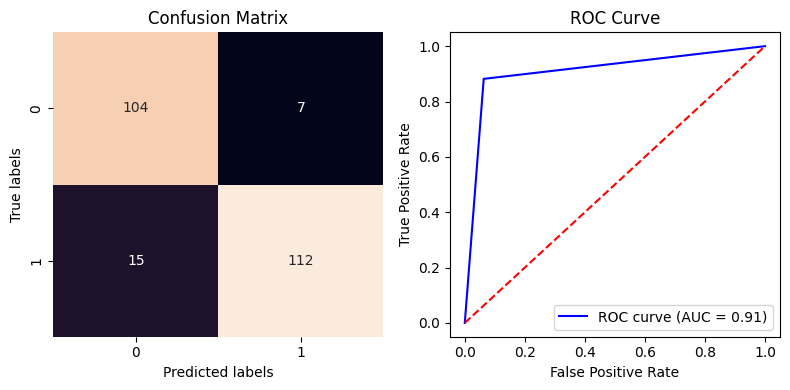

In [ ]:
# Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=100)

# Parameters to tune
param_grid_dt = {
    'max_depth': range(3, 20),
    'min_samples_split': range(2, 20),
    'min_samples_leaf': range(1, 10)
}

# Instantiate RandomizedSearchCV
random_search_dt = RandomizedSearchCV(dt, param_distributions=param_grid_dt, n_iter=100,
                                      cv=5, scoring='accuracy', n_jobs=-1, random_state=42)

# Fit RandomizedSearchCV to the training data
random_search_dt.fit(X_train_resampled, y_train_resampled)

# Get the best parameters
best_params_dt = random_search_dt.best_params_
print("Best Parameters for Decision Tree:", best_params_dt)

# Get the best classifier model after hyperparameter tuning
best_dt = random_search_dt.best_estimator_

# Fit the best model to the training data
best_dt.fit(X_train_resampled, y_train_resampled)

# Predict on the testing data
y_pred_dt_tuned = best_dt.predict(X_test)

# Generate the model test classification report for Tuned Decision Tree
report_dt_tuned = classification_report(y_test, y_pred_dt_tuned)
print("Tuned Decision Tree Classification Report:")
print(report_dt_tuned)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_dt_tuned)

# Calculate the AUC score
auc_score = roc_auc_score(y_test, y_pred_dt_tuned)

# Calculate the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_dt_tuned)

# Plot confusion matrix and ROC curve side by side
plt.figure(figsize=(8, 4))

# Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='blue', label='ROC curve (AUC = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()


## Ensemblement

Voting Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       111
           1       0.96      0.95      0.96       127

    accuracy                           0.95       238
   macro avg       0.95      0.95      0.95       238
weighted avg       0.95      0.95      0.95       238



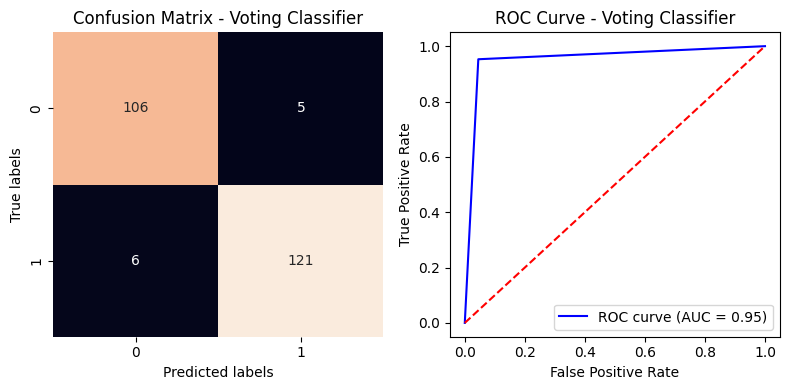

In [ ]:
# Best Parameters for each model
rf_best_params = best_params_rf
svm_best_params = {'kernel': 'rbf', 'gamma': 1, 'C': 10}
lr_best_params = best_params_lr
xgb_best_params = best_params_xgb
dt_best_params = best_params_dt

# Initialize the models with best parameters
rf = RandomForestClassifier(**rf_best_params, random_state=100)
svm = SVC(**svm_best_params, probability=True, random_state=100)
lr = LogisticRegression(**lr_best_params, random_state=100)
xgb = XGBClassifier(**xgb_best_params, random_state=100)
dt = DecisionTreeClassifier(**dt_best_params, random_state=100)

# List of (name, estimator) tuples for Voting Classifier
estimators = [('Random Forest', rf), ('SVM', svm), ('Logistic Regression', lr), ('XGBoost', xgb), ('Decision Tree', dt)]

# Voting Classifier using soft voting
voting_clf = VotingClassifier(estimators=estimators, voting='soft')

# Fit the Voting Classifier to the training data
voting_clf.fit(X_train_resampled, y_train_resampled)

# Predict on the testing data
y_pred_voting = voting_clf.predict(X_test)

# Generate the classification report
report_voting = classification_report(y_test, y_pred_voting)
print("Voting Classifier Classification Report:")
print(report_voting)

# Calculate the confusion matrix
cm_voting = confusion_matrix(y_test, y_pred_voting)

# Calculate the AUC score
auc_score_voting = roc_auc_score(y_test, y_pred_voting)

# Calculate the ROC curve
fpr_voting, tpr_voting, _ = roc_curve(y_test, y_pred_voting)

# Plot confusion matrix and ROC curve side by side
plt.figure(figsize=(8, 4))

# Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm_voting, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix - Voting Classifier')

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr_voting, tpr_voting, color='blue', label='ROC curve (AUC = %0.2f)' % auc_score_voting)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Voting Classifier')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()


## **Prediction App using tuned XGBoost Classifier Model**

In [ ]:

def predict_heart_condition(model, data):
    prediction = model.predict(data)
    if prediction == 0:
        return "Normal heart condition"
    else:
        return "Heart disease detected"

# Best XGBoost Classifier model
best_xgb_clf = xgb_grid.best_estimator_

# Sample user inputs
arrList = []

def get_values(parameter_name, description, valid_range=None):
    value = None
    while True:
        try:
            value = float(input(f"{description}: "))
            if valid_range and value not in valid_range:
                raise ValueError
            break
        except ValueError:
            print(f"Invalid input! Please enter a valid value in the range {valid_range}.")

    return value

# Gender
gender = get_values('gender', "Gender (0 for female, 1 for male)", valid_range=[0, 1])
arrList.append(gender)

# Age
age = get_values('age', "Age in years")
arrList.append(age)

# Chest Pain Type
print("Chest Pain Type:")
print("1: Typical Angina")
print("2: Atypical Angina")
print("3: Non-Anginal Pain")
print("4: Asymptomatic")
chest_pain_type = get_values('chest_pain_type', "Enter Chest Pain Type (1-4)", valid_range=[1, 2, 3, 4])
arrList.append(chest_pain_type)

# Resting Blood Pressure (in mm Hg)
resting_bp_s = get_values('resting_bp_s', "Resting Blood Pressure (mm Hg)")
arrList.append(resting_bp_s)

# Serum Cholesterol (in mg/dl)
cholesterol = get_values('cholesterol', "Serum Cholesterol (mg/dl)")
arrList.append(cholesterol)

# Fasting Blood Sugar (1 for True, 0 for False)
fasting_blood_sugar = get_values('fasting_blood_sugar', "Fasting Blood Sugar (> 120 mg/dl) (1 for True, 0 for False)", valid_range=[0, 1])
arrList.append(fasting_blood_sugar)

# Resting Electrocardiogram Results
print("Resting Electrocardiogram Results:")
print("0: Normal")
print("1: Abnormal (ST-T wave abnormality)")
print("2: Abnormal (Left ventricular hypertrophy)")
rest_ecg = get_values('rest_ecg', "Resting Electrocardiogram Results (0-2)", valid_range=[0, 1, 2])
arrList.append(rest_ecg)

# Maximum Heart Rate Achieved (71-202)
max_heart_rate = get_values('max_heart_rate', "Maximum Heart Rate Achieved (71-202)")
arrList.append(max_heart_rate)

# Exercise Induced Angina (1 for Yes, 0 for No)
exer_angina = get_values('exer_angina', "Exercise Induced Angina (1 for Yes, 0 for No)", valid_range=[0, 1])
arrList.append(exer_angina)

# Oldpeak (ST depression induced by exercise relative to rest)
oldpeak = get_values('oldpeak', "Oldpeak (ST depression induced by exercise relative to rest)")
arrList.append(oldpeak)

# The Slope of the Peak Exercise ST Segment
print("The Slope of the Peak Exercise ST Segment:")
print("1: Upsloping")
print("2: Flat")
print("3: Downsloping")
st_slope = get_values('st_slope', "The Slope of the Peak Exercise ST Segment (1-3)", valid_range=[1, 2, 3])
arrList.append(st_slope)

# Converting list to NumPy array and reshaping it
arrList_np = np.array(arrList)
reshaped_arr = arrList_np.reshape(1, -1)

# Predict heart condition
prediction = predict_heart_condition(best_xgb_clf, reshaped_arr)
print("\nPrediction:", f"\033[1m{prediction}\033[0m")


## **Group-Based Performance Evaluation**

In [ ]:
#Import normalized data
#Load data
df1 = pd.read_csv('preprocessed_heart_statlog_cleveland_hungary_final_scaled.csv')
df1.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,1,0.70,0.479270,0,0,0.788732,0,0.295455,1,0
1,49,0,2,0.80,0.298507,0,0,0.676056,0,0.409091,2,1
2,37,1,1,0.65,0.469320,0,1,0.267606,0,0.295455,1,0
3,48,0,3,0.69,0.354892,0,0,0.338028,1,0.465909,2,1
4,54,1,2,0.75,0.323383,0,0,0.436620,0,0.295455,1,0


In [ ]:


# Define age groups
age_bins = [0, 30, 40, 50, 60, 100]
age_labels = ['<30', '30-40', '41-50', '51-60', '>60']
df1['age_group'] = pd.cut(df1['age'], bins=age_bins, labels=age_labels)

# Preprocessing steps (handle missing values, encode categorical variables, etc.)
# Assume 'target' is the target variable
X = df1.drop(columns=['target', 'age_group'])  # Exclude 'age_group' from features
y = df1['target']

# Train-test split with test size 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Best parameters for each model
rf_best_params = best_params_rf  # Example: {'n_estimators': 100, 'max_depth': 10}
svm_best_params = {'kernel': 'rbf', 'gamma': 1, 'C': 10}
lr_best_params = best_params_lr  # Example: {'C': 1.0, 'solver': 'lbfgs'}
xgb_best_params = best_params_xgb  # Example: {'n_estimators': 100, 'learning_rate': 0.1}
dt_best_params = best_params_dt  # Example: {'max_depth': 5}

# Initialize models with best parameters
models = {
    'Random Forest': RandomForestClassifier(**rf_best_params),
    'SVM': SVC(**svm_best_params, probability=True),
    'Logistic Regression': LogisticRegression(**lr_best_params),
    'XGBoost': XGBClassifier(**xgb_best_params),
    'Decision Tree': DecisionTreeClassifier(**dt_best_params)
}

# Train the models
for model_name, model in models.items():
    model.fit(X_train, y_train)

# Function to evaluate model performance for different groups
def evaluate_group_performance(model, X_test, y_test, group_column):
    results = {metric: [] for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']}
    groups = X_test[group_column].unique()

    for group in groups:
        group_data = X_test[X_test[group_column] == group]
        y_true = y_test.loc[group_data.index]

        # Check if all samples in y_true belong to the same class
        if len(y_true.unique()) == 1:
            print(f"Skipping evaluation for {group_column} '{group}' due to only one class present.")
            # Append NaNs to results for this group
            for metric in results:
                results[metric].append(None)
            continue

        y_pred = model.predict(group_data.drop(columns=[group_column]))
        y_prob = model.predict_proba(group_data.drop(columns=[group_column]))[:, 1]

        results['accuracy'].append(accuracy_score(y_true, y_pred))
        results['precision'].append(precision_score(y_true, y_pred))
        results['recall'].append(recall_score(y_true, y_pred))
        results['f1'].append(f1_score(y_true, y_pred))

        # Check if there are samples from both classes in y_true before calculating roc_auc
        if len(y_true.unique()) > 1:
            results['roc_auc'].append(roc_auc_score(y_true, y_prob))
        else:
            results['roc_auc'].append(None)  # Set to None if roc_auc is undefined

    # Create DataFrame with results and ensure correct index alignment
    performance_df = pd.DataFrame(results, index=groups)
    performance_df = performance_df.reindex(age_labels)  # Reindex to ensure all age groups are included

    return performance_df

# Ensure 'age_group' is in the test set
X_test['age_group'] = pd.cut(X_test['age'], bins=age_bins, labels=age_labels)

# Evaluate performance for each model
models_performance = {}
for model_name, model in models.items():
    print(f"Evaluating {model_name} performance by Age Group")
    performance = evaluate_group_performance(model, X_test, y_test, 'age_group')
    models_performance[model_name] = performance
    print(performance)
    print("\n")



Evaluating Random Forest performance by Age Group
Skipping evaluation for age_group '<30' due to only one class present.
       accuracy  precision    recall        f1   roc_auc
<30         NaN        NaN       NaN       NaN       NaN
30-40  0.950000   1.000000  0.875000  0.933333  1.000000
41-50  0.965517   0.964286  0.964286  0.964286  0.967262
51-60  0.906542   0.893939  0.951613  0.921875  0.964158
>60    0.980392   1.000000  0.969697  0.984615  1.000000


Evaluating SVM performance by Age Group
Skipping evaluation for age_group '<30' due to only one class present.
       accuracy  precision    recall        f1   roc_auc
<30         NaN        NaN       NaN       NaN       NaN
30-40  1.000000   1.000000  1.000000  1.000000  1.000000
41-50  0.793103   0.807692  0.750000  0.777778  0.929762
51-60  0.915888   0.934426  0.919355  0.926829  0.957706
>60    0.921569   0.914286  0.969697  0.941176  0.974747


Evaluating Logistic Regression performance by Age Group
Skipping evaluation for 

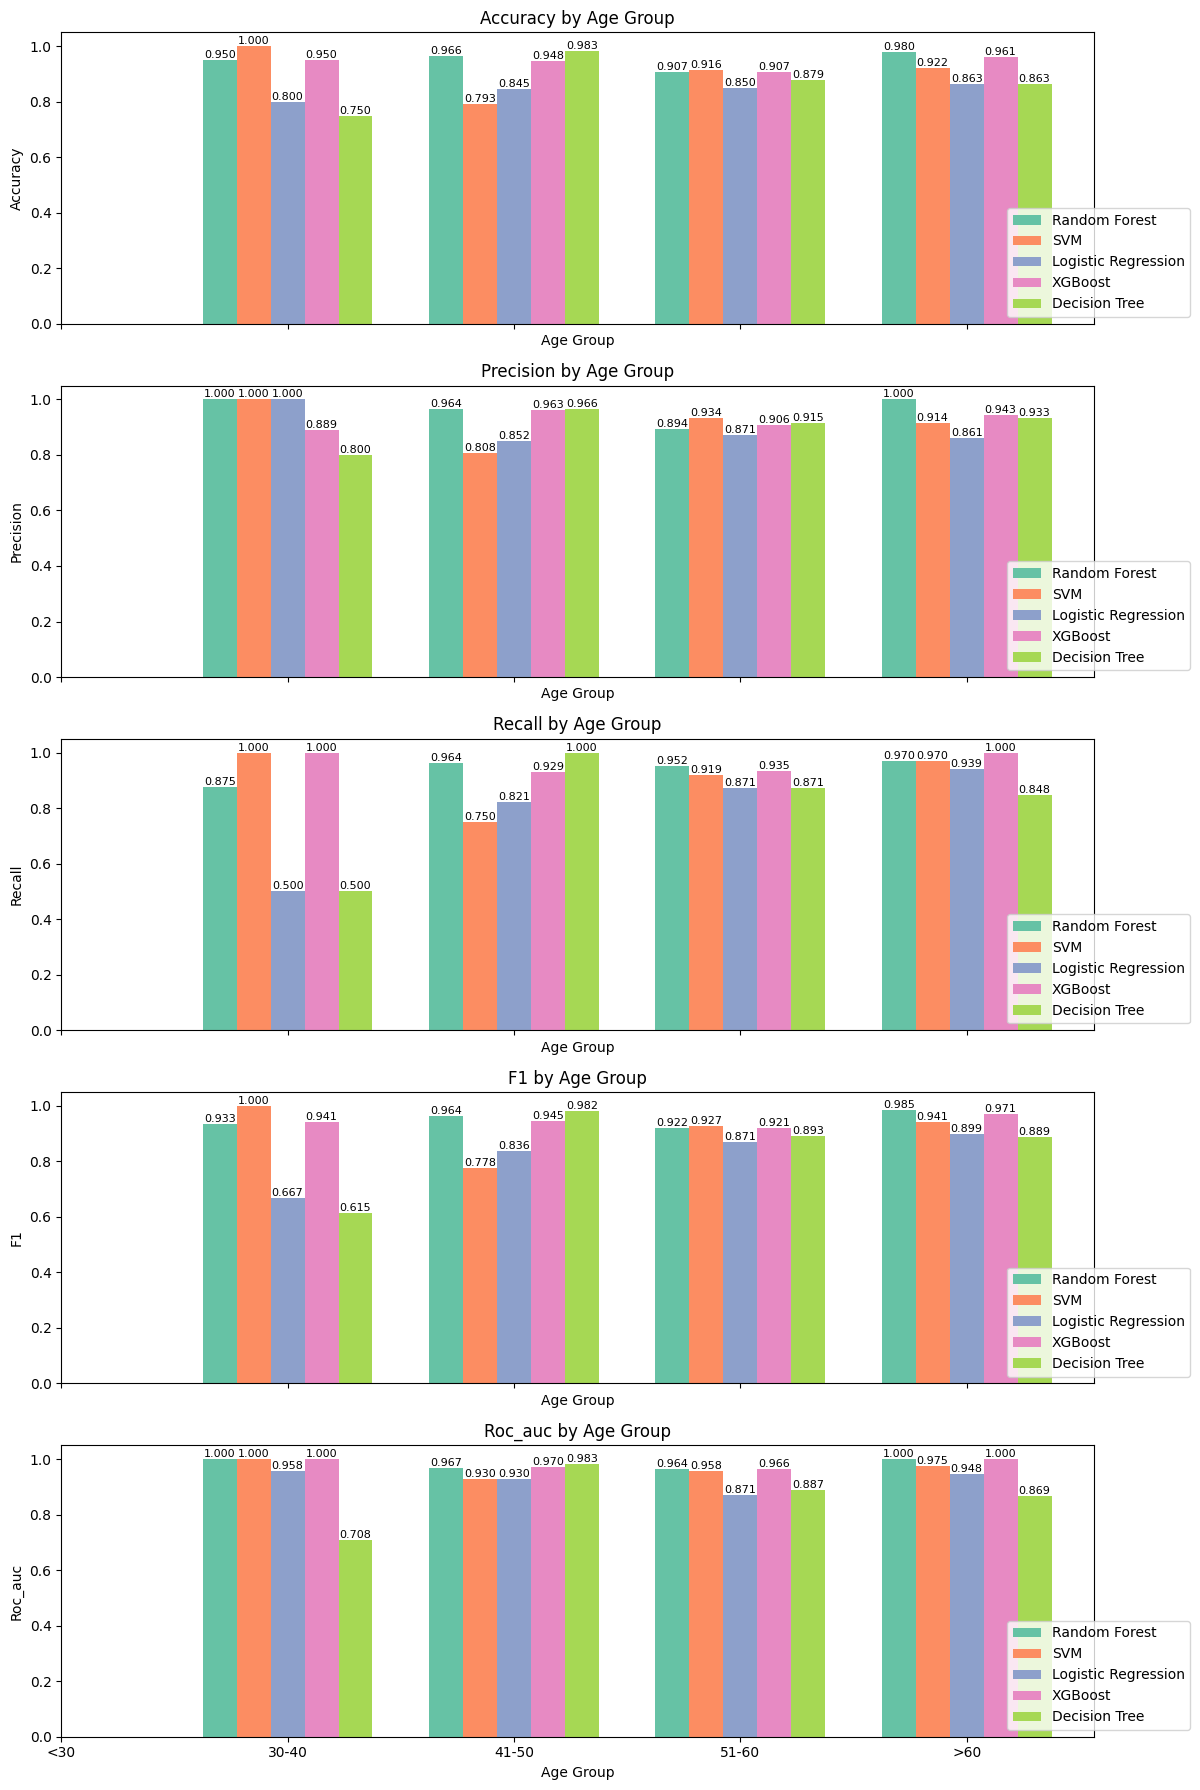

In [ ]:
def plot_metrics_comparison_all_models(models_performance):
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

    # Define colors for each model
    colors = sns.color_palette("Set2", len(models_performance))

    fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(12, 18), sharex=True)

    # Iterate over metrics
    for i, metric in enumerate(metrics):
        # Initialize x positions for grouped bar plots
        x = np.arange(len(age_labels))
        width = 0.15

        # Iterate over models
        for j, (model_name, performance) in enumerate(models_performance.items()):
            # Plot bars for each model
            bars = axes[i].bar(x + j * width, performance[metric], width=width, label=model_name, color=colors[j])

            # Annotate each bar with its value (skip NaN values)
            for bar in bars:
                yval = bar.get_height()
                if np.isnan(yval):
                    continue
                axes[i].text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.3f}', ha='center', va='bottom', fontsize=8)

        # Set labels and title for each subplot
        axes[i].set_ylabel(metric.capitalize())
        axes[i].set_xlabel('Age Group')
        axes[i].set_title(f'{metric.capitalize()} by Age Group')
        axes[i].set_xticks(x + (len(models_performance) / 2 - 0.5) * width)
        axes[i].set_xticklabels(age_labels)

        # Place the legend outside the plot area at bottom right
        axes[i].legend(loc='lower right', bbox_to_anchor=(1.1, 0))

    plt.tight_layout()
    plt.show()

# Plot performance metrics comparison for all models using grouped bar plots
plot_metrics_comparison_all_models(models_performance)


## Model Performance Analysis by Age Group

### Random Forest:
- **Performance:** Generally high across all age groups except '<30', where evaluation was skipped due to insufficient data.
- **Highlights:**
  - Highest accuracy in the '>60' age group (98.04%).
  - Good balance of precision, recall, and F1 score across most age groups.
  - Strong ROC-AUC scores indicate good discrimination ability in predicting the positive class.

### SVM (Support Vector Machine):
- **Performance:** Varied significantly across age groups.
- **Highlights:**
  - Perfect accuracy and metrics in the '30-40' age group, indicating ideal classification performance.
  - Decline in performance in the '41-50' age group, especially in precision and recall.
  - Generally strong ROC-AUC scores across all age groups, indicating good overall discriminative ability.

### Logistic Regression:
- **Performance:** Shows consistent but moderate performance across age groups.
- **Highlights:**
  - Significant drop in metrics in the '<30' age group, possibly due to data imbalance or insufficient samples.
  - Stable performance in precision, recall, and F1 score metrics across '41-50' and '51-60' age groups.
  - ROC-AUC scores are relatively stable but lower compared to other models in some age groups.

### XGBoost:
- **Performance:** Generally high across most age groups.
- **Highlights:**
  - Excellent performance in the '30-40' age group with perfect precision and recall.
  - Strong performance metrics across all other age groups, indicating robustness and consistency.
  - High ROC-AUC scores across all age groups, suggesting excellent discriminative power.

### Decision Tree:
- **Performance:** Shows a mix of strong and moderate performance across age groups.
- **Highlights:**
  - Highest accuracy and F1 score in the '41-50' age group, indicating optimal model fit.
  - Precision and recall vary across age groups, with occasional drops in the '>60' age group.
  - ROC-AUC scores are generally good but show some variability compared to other models.

### Conclusion:
- **Model Selection:** XGBoost generally performs the best across age groups, with consistently high metrics and ROC-AUC scores.
- **Age Group Insights:** Performance variation across age groups underscores the importance of age-specific model evaluation and customization.
- **Further Considerations:** Addressing data imbalance or inadequate sample size in certain age groups (<30) could improve overall model performance and reliability.


